In [1]:
print('FIFA World Cup 2026 Project')

FIFA World Cup 2026 Project


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

print("ok")

ok


# Analytic Task 1 - Player Shooting Efficiency

## FIFA World Cup 2026

##Analytic Question: Do forwards and midfielders differ significantly in their average shooting accuracy during the FIFA World Cup 2026? The analysis will investigate player-level shooting performace using official tournament statistics available throght the approved data sources.

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

In [ ]:
shooting=pd.read_clipboard(sep=',')

In [ ]:
shooting.head()

In [ ]:
shooting.to_csv('/Users/apuu/Desktop/Data_Science_Assessment2/Data/raw/player_shooting_raw.csv', index=False)
print('Raw shooting data saved.')


In [9]:
shooting= pd.read_csv('/Users/apuu/Desktop/Data_Science_Assessment2/Data/raw/player_shooting_raw.csv')
shooting.head()

,Rk,Player,Pos,Squad,Age,Born,90s,Gls,Sh,SoT,SoT%,Sh/90,SoT/90,G/Sh,G/SoT,PK,PKatt,Matches,-9999
0,1,Brenden Aaronson,MF,us USA,25,2000,0.8,0,3,1,33.3,3.55,1.18,0.0,0.0,0,0,Matches,5bc43860
1,2,Thelo Aasgaard,MF,no Norway,24,2002,1.0,1,2,1,50.0,2.00,1.00,0.5,1.0,0,0,Matches,c88a28b9
2,3,Hamza Abdelkarim,FW,eg Egypt,18,2008,0.7,0,0,0,NaN,0.00,0.00,NaN,NaN,0,0,Matches,057d8f12
3,4,Hossam Abdelmaguid,DF,eg Egypt,25,2001,0.7,0,0,0,NaN,0.00,0.00,NaN,NaN,0,0,Matches,accbfc94
4,5,Mohamed Abdelmonem,DF,eg Egypt,27,1999,0.2,0,0,0,NaN,0.00,0.00,NaN,NaN,0,0,Matches,bff15d74


In [10]:
shooting.columns.tolist()

['Rk',
 'Player',
 'Pos',
 'Squad',
 'Age',
 'Born',
 '90s',
 'Gls',
 'Sh',
 'SoT',
 'SoT%',
 'Sh/90',
 'SoT/90',
 'G/Sh',
 'G/SoT',
 'PK',
 'PKatt',
 'Matches',
 '-9999']

In [11]:
shooting.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1039 entries, 0 to 1038
Data columns (total 19 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Rk       1039 non-null   int64  
 1   Player   1039 non-null   object 
 2   Pos      1039 non-null   object 
 3   Squad    1039 non-null   object 
 4   Age      1039 non-null   int64  
 5   Born     1039 non-null   int64  
 6   90s      1039 non-null   float64
 7   Gls      1039 non-null   int64  
 8   Sh       1039 non-null   int64  
 9   SoT      1039 non-null   int64  
 10  SoT%     680 non-null    float64
 11  Sh/90    1039 non-null   float64
 12  SoT/90   1039 non-null   float64
 13  G/Sh     680 non-null    float64
 14  G/SoT    396 non-null    float64
 15  PK       1039 non-null   int64  
 16  PKatt    1039 non-null   int64  
 17  Matches  1039 non-null   object 
 18  -9999    1039 non-null   object 
dtypes: float64(6), int64(8), object(5)
memory usage: 154.4+ KB


In [12]:
shooting['Pos'].value_counts()

Pos
MF      344
DF      306
FW      159
FWMF     77
GK       62
DFMF     40
MFFW     36
MFDF     12
DFFW      3
Name: count, dtype: int64

In [13]:
shooting_filtered = shooting[
    shooting['Pos'].isin(['FW', 'MF'])
].copy()

shooting_filtered['Pos'].value_counts()

Pos
MF    344
FW    159
Name: count, dtype: int64

In [14]:
print("Players with zero shots:", (shooting_filtered['Sh'] == 0).sum())
print("Players with missing SoT%:", shooting_filtered['SoT%'].isnull().sum())

Players with zero shots: 107
Players with missing SoT%: 107


In [15]:
shooting_filtered = shooting_filtered[
    shooting_filtered['Sh'] > 0
].copy()

shooting_filtered.shape

(396, 19)

In [16]:
shooting_filtered['Pos'].value_counts()

Pos
MF    268
FW    128
Name: count, dtype: int64

In [17]:
shooting_filtered['Shooting_Accuracy'] = (
    shooting_filtered['SoT'] / shooting_filtered['Sh']
) * 100

shooting_filtered[['Player', 'Pos', 'Sh', 'SoT', 'SoT%', 'Shooting_Accuracy']].head()

,Player,Pos,Sh,SoT,SoT%,Shooting_Accuracy
0,Brenden Aaronson,MF,3,1,33.3,33.333333
1,Thelo Aasgaard,MF,2,1,50.0,50.000000
16,Ché Adams,FW,1,1,100.0,100.000000
27,Ali Ahmed,MF,2,1,50.0,50.000000
35,Kerem Aktürkoğlu,FW,3,1,33.3,33.333333


In [18]:
shooting_filtered['Accuracy_Difference'] = (
    shooting_filtered['Shooting_Accuracy'] - shooting_filtered['SoT%']
).abs()

shooting_filtered['Accuracy_Difference'].max()

0.04615384615384954

In [19]:
shooting_filtered['Sh'].describe()

count    396.000000
mean       4.487374
std        4.598001
min        1.000000
25%        2.000000
50%        3.000000
75%        5.000000
max       41.000000
Name: Sh, dtype: float64

In [20]:
shooting_filtered['Sh'].value_counts().sort_index().head(10)

Sh
1     88
2     66
3     64
4     50
5     31
6     25
7     10
8     13
9      9
10     9
Name: count, dtype: int64

In [21]:
shooting_filtered[shooting_filtered['Sh'] >= 3]['Pos'].value_counts()

Pos
MF    161
FW     81
Name: count, dtype: int64

In [22]:
eligible_players = shooting_filtered[
    shooting_filtered['Sh'] >= 3
].copy()

eligible_players['Pos'].value_counts()

Pos
MF    161
FW     81
Name: count, dtype: int64

In [23]:
eligible_players.duplicated(subset=['Player', 'Squad']).sum()

np.int64(0)

In [24]:
eligible_players[
    ['Player', 'Pos', 'Sh', 'SoT', 'Shooting_Accuracy']
].isnull().sum()

Player               0
Pos                  0
Sh                   0
SoT                  0
Shooting_Accuracy    0
dtype: int64

In [25]:
eligible_players.to_csv(
    '/Users/apuu/Desktop/Data_Science_Assessment2/Data/cleaned/task1_shooting_cleaned.csv',
    index=False
)

print("Cleaned dataset saved.")

Cleaned dataset saved.


In [26]:
fw_sample = eligible_players[
    eligible_players['Pos'] == 'FW'
].sample(n=50, random_state=42)

mf_sample = eligible_players[
    eligible_players['Pos'] == 'MF'
].sample(n=50, random_state=42)

sample_players = pd.concat([fw_sample, mf_sample])

sample_players['Pos'].value_counts()

Pos
FW    50
MF    50
Name: count, dtype: int64

In [27]:
sample_players.groupby('Pos')['Shooting_Accuracy'].agg(
    ['count', 'mean', 'median', 'std', 'min', 'max']
)

,count,mean,median,std,min,max
Pos,,,,,,
FW,50,40.598895,42.222222,23.806404,0.0,100.0
MF,50,32.891132,33.333333,23.210910,0.0,80.0


In [28]:
sample_players.groupby('Pos')['Shooting_Accuracy'].agg(
    variance='var',
    q1=lambda x: x.quantile(0.25),
    q3=lambda x: x.quantile(0.75),
    iqr=lambda x: x.quantile(0.75) - x.quantile(0.25)
)

,variance,q1,q3,iqr
Pos,,,,
FW,566.744866,28.928571,56.793478,27.864907
MF,538.746366,16.666667,50.000000,33.333333


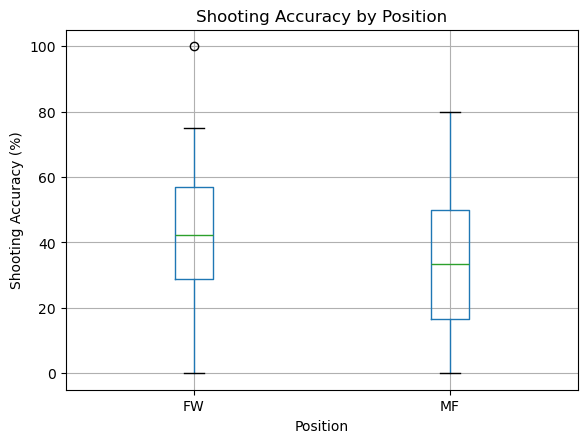

In [29]:
sample_players.boxplot(
    column='Shooting_Accuracy',
    by='Pos'
)

plt.title('Shooting Accuracy by Position')
plt.suptitle('')
plt.xlabel('Position')
plt.ylabel('Shooting Accuracy (%)')
plt.show()

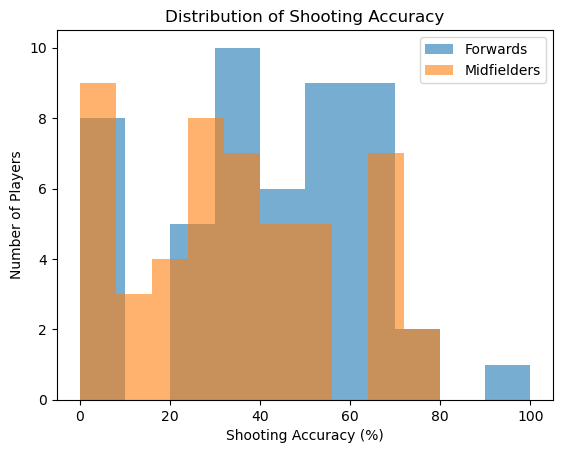

In [30]:
fw = sample_players[sample_players['Pos'] == 'FW']['Shooting_Accuracy']
mf = sample_players[sample_players['Pos'] == 'MF']['Shooting_Accuracy']

plt.hist(fw, bins=10, alpha=0.6, label='Forwards')
plt.hist(mf, bins=10, alpha=0.6, label='Midfielders')

plt.title('Distribution of Shooting Accuracy')
plt.xlabel('Shooting Accuracy (%)')
plt.ylabel('Number of Players')
plt.legend()
plt.show()

In [31]:
fw_mean = fw.mean()
fw_sem = stats.sem(fw)
fw_ci = stats.t.interval(
    confidence=0.95,
    df=len(fw)-1,
    loc=fw_mean,
    scale=fw_sem
)

mf_mean = mf.mean()
mf_sem = stats.sem(mf)
mf_ci = stats.t.interval(
    confidence=0.95,
    df=len(mf)-1,
    loc=mf_mean,
    scale=mf_sem
)

print("Forwards 95% CI:", fw_ci)
print("Midfielders 95% CI:", mf_ci)

Forwards 95% CI: (np.float64(33.833190109415305), np.float64(47.36460036382274))
Midfielders 95% CI: (np.float64(26.294663901372623), np.float64(39.48759944931178))


In [32]:
t_stat, p_value = stats.ttest_ind(
    fw,
    mf,
    equal_var=False
)

print("t-statistic:", t_stat)
print("p-value:", p_value)

t-statistic: 1.6392143035103708
p-value: 0.1043771700162047


#### we fail to reject the null hypothesis because 0.104 > 0.05

## Two-Sample t-Test

**Null hypothesis (H₀):**  
There is no significant difference in the mean shooting accuracy of forwards and midfielders at the FIFA World Cup 2026.

**Alternative hypothesis (H₁):**  
There is a significant difference in the mean shooting accuracy of forwards and midfielders at the FIFA World Cup 2026.

A Welch two-sample t-test was conducted using a significance level of 0.05.

The test produced a t-statistic of approximately 1.639 and a p-value of approximately 0.104.

Since the p-value is greater than 0.05, the null hypothesis is not rejected. Although forwards recorded a higher sample mean shooting accuracy than midfielders, the difference was not statistically significant at the 5% significance level.

## 95% Confidence Intervals

The 95% confidence interval for the mean shooting accuracy of forwards was approximately **33.83% to 47.36%**.

The 95% confidence interval for the mean shooting accuracy of midfielders was approximately **26.29% to 39.49%**.

These intervals provide a reasonable range for the population mean shooting accuracy of each position group based on the selected sample. The intervals overlap, which is consistent with the t-test result that did not find a statistically significant difference between forwards and midfielders at the 5% significance level.

## Population and Sampling

This analysis was done with the population that consisted of FIFA World Cup 2026 players who were classified specifically as forwards (FW) or midfielders (MF) and had atleast three shots during the tournament.

After applying these eligibility criteria, 242 players remained:
- 81 forwards
- 161 midfielders

A stratified random sample was then selected by position. A random sample of 50 forwards and 50 midfielders was selected, thus there was a total sample of 100 players.

From each position group, the same numbner of players was selected thus allowing a balanced comparison between forwards and midfielders. To reproduce the same sample, a fixed random state was used in Pythhon. 

In [34]:
print('Forward skewness:', fw.skew())

Forward skewness: -0.17353431902805455


In [35]:
print('midfielder skewness:', mf.skew())

midfielder skewness: 0.2555846373583823


## Assumption Check

The distributions of shooting accuracy were inspected using the histograms and skewness value for both forwards and midfielders.

Both the skewness are close to zero, thus neither of them are strongly skewed.

Each group had  50 observations. So, the Central Limit Theorem supports the use of the two-sample t-test because the sampling distribution of the mean is expected to be approximately normal for sufficiently large sample.

The sample variances were also similar between forwards and midfielders.

## Descriptive Statistics

The stratified random sample contained 50 forwards and 50 midfielders.

Forwards recorded a mean shooting accuracy of approximately 40.60%, with a median of 42.22% and a standard deviation of 23.81%.

Midfielders recorded a mean shooting accuracy of approximately 32.89%, with a median of 33.33% and a standard deviation of 23.21%.

The interquartile range was approximately 27.86 percentage points for forwards and 33.33 percentage points for midfielders.

Overall, forwards showed a higher average shooting accuracy in the sample, although there was substantial variation within both position groups.

## Data Wrangling and Preparation

The original FBref player shooting dataset contained 1,039 player records.

We only took the players classified specifically as forwards(FW) or midfielders(MF) for this analysis. Other players that had mixed positional comparison were excluded so as to make a clear compariosn between two groups.

Players who recorded zero shots were excluded because shooting accuracy cannot be calculated for those who have no shots.

A minimum threshold of three shots was applied to reduce influence of players who had only one or two shots. Thus, 242 eligible players remained, consisting of 81 forwards and 161 midfielders.

A new variable, 'Shooting_Accuracy', was created using:

Shooting Accuracy = (Shots on Target / Total Shots) × 100

The calculated values were compared with FBref's published 'SoT%' values. The largest difference was approximately 0.046 percentage points.

The eligible dataset was also checked for duplicate player records and missing values in the variables required for analysis. No duplicates or missing values were identified in the final analysis variables.

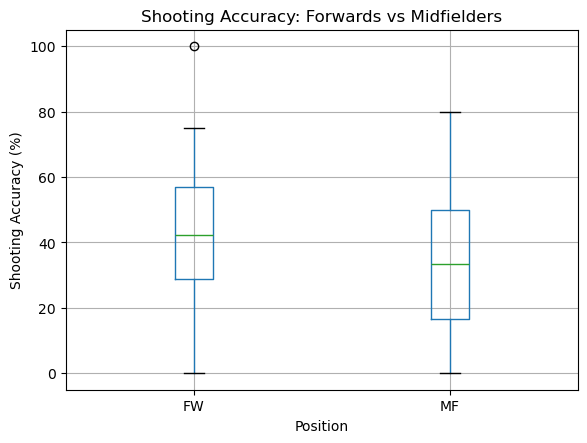

In [37]:
sample_players.boxplot(
    column='Shooting_Accuracy',
    by='Pos'
)

plt.title('Shooting Accuracy: Forwards vs Midfielders')
plt.suptitle('')
plt.xlabel('Position')
plt.ylabel('Shooting Accuracy (%)')

plt.savefig(
    '/Users/apuu/Desktop/Data_Science_Assessment2/figure/task1_shooting_boxplot.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

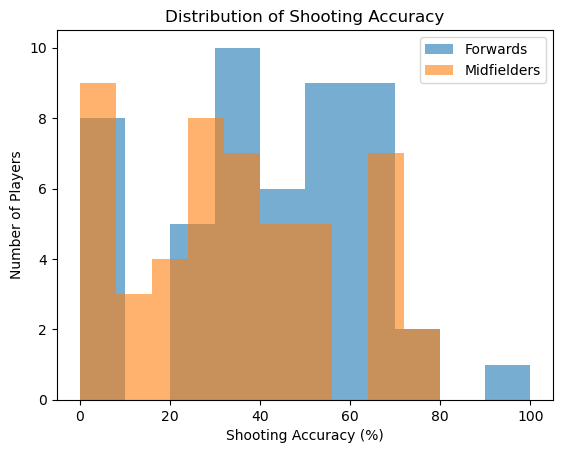

In [38]:
plt.hist(fw, bins=10, alpha=0.6, label='Forwards')
plt.hist(mf, bins=10, alpha=0.6, label='Midfielders')

plt.title('Distribution of Shooting Accuracy')
plt.xlabel('Shooting Accuracy (%)')
plt.ylabel('Number of Players')
plt.legend()

plt.savefig(
    '/Users/apuu/Desktop/Data_Science_Assessment2/figure/task1_shooting_histogram.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

## Conclusion and Limitations

The analysis found that forwards had a higher mean shooting accuracy than midfielders in the selected sample. Forwards had an average shooting accuracy of approximately 40.60%, while it was 32.89% for midfielders.

However, the two-sample t-test produced a p-value of approximately 0.104, which is greater than the significance level of 0.05. So, there was insufficient statistical evidence to conclude that the population mean shooting accuracy differed between forwards and midfielders at the FIFA World Cup 2026.

A limitation of the analysis is that shooting accuracy can vary considerably when players have relatively few attempts. To reduce this effect, only players who recorded at least three shots were used in our analysis. The analysis also considered only players classified specifically as forwards or midfielders.

In [41]:
sample_players.to_csv(
    '/Users/apuu/Desktop/Data_Science_Assessment2/Data/cleaned/task1_sample_100_players.csv',
    index=False)

### Source Reference

Source: FBref  
Dataset: FIFA World Cup 2026 – Player Shooting Statistics  
URL: https://fbref.com/en/comps/1/shooting/World-Cup-Stats  
Accessed: 4 September 2026  

The Player Shooting table was obtained using FBref's Share & Export CSV option. The raw dataset was preserved before cleaning and analysis in Python.

In [42]:
summary_table = pd.DataFrame({
    'Position': ['Forwards', 'Midfielders'],
    'Sample Size': [50, 50],
    'Mean Accuracy (%)': [fw.mean(), mf.mean()],
    'Median Accuracy (%)': [fw.median(), mf.median()],
    'Standard Deviation': [fw.std(), mf.std()],
    '95% CI Lower': [fw_ci[0], mf_ci[0]],
    '95% CI Upper': [fw_ci[1], mf_ci[1]]
})

summary_table.round(2)

,Position,Sample Size,Mean Accuracy (%),Median Accuracy (%),Standard Deviation,95% CI Lower,95% CI Upper
0,Forwards,50,40.60,42.22,23.81,33.83,47.36
1,Midfielders,50,32.89,33.33,23.21,26.29,39.49


In [44]:
summary_table.round(2).to_csv(
    '/Users/apuu/Desktop/Data_Science_Assessment2/Data/cleaned/task1_summary_table.csv',
    index=False
)